In [4]:
import os
import copy
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from datetime import datetime
from torch.utils.data import DataLoader

from cocodeel.dataset import CovarDataset
from cocodeel.model import BaseNetwork
from cocodeel.posthoc_model import PostHocCovarNetwork

Idea: Simulate data so that strength of, omitted variable bias, mediated and residual effect have same magnitude.

$ y = X^\top \vec\beta_X + z \beta_z + \epsilon_y $, $ X = z \vec\delta_z + \epsilon_x $ and $Z = \epsilon_z$ with $\epsilon_y \sim \mathcal{N}(0, 1)$, $\epsilon_x \sim \mathcal{N}(0, I_q)$ and $\epsilon_z \sim \mathcal{N}(0, 1)$.

Optimal parameters: $\beta_x = \sqrt{\frac{3}{2q}}$, $\beta_z \in [0, 2]$, $\delta_z = \sqrt{\frac{2}{q}}$.






In [5]:
# ----------------------------
# Simulated dataset
# ----------------------------
def simulate_data(N=3000, q=255, bz=1.0):
    # Simulation parameters
    bx_opt = (3 / (2 * q)) ** 0.5
    bX = bx_opt * torch.ones((q,1))
    bX[:q//3,] = 0
    dz_opt = (2 / q) ** 0.5
    #dz_opt = 1
    dZ = dz_opt * torch.ones((q,1))
    dZ[q//3:,] = 0
    # Simulate Z, X, fz, fx, y.
    Z = 1 + torch.randn(N, 1)
    ex = torch.randn(N, q)
    X = 1 + Z @ dZ.t() + ex
    # Effects
    fz = Z * bz
    fx = X @ bX
    fr = ex @ bX
    # Means of effects.
    fz_mean = torch.mean(fz)
    fx_mean = torch.mean(fx)
    fr_mean = torch.mean(fr)
    # Center effects.
    fz = fz - fz_mean
    fx = fx - fx_mean
    fr = fr - fr_mean
    # Response
    y = fz_mean + fx_mean + fz + fx + torch.randn(N, 1)
    return X, Z, y, fx, fz, fr

In [6]:
# ----------------------------
# Backbones
# ----------------------------
class IdentityBackbone(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.model = nn.Identity()
    def forward(self, x):
        return self.model(x)

class ShallowBackbone(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.model = nn.Sequential(
            nn.Linear(in_features, out_features),
            nn.ReLU()
        )
    def forward(self, x):
        return self.model(x)

class DeepBackbone(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.model = nn.Sequential(
            nn.Linear(in_features, 2 * in_features),
            nn.ReLU(),
            nn.Linear(2 * in_features, 2 * out_features),
            nn.ReLU(),
            nn.Linear(2 * out_features, 2 * out_features),
            nn.ReLU(),
            nn.Linear(2 * out_features, out_features),
            nn.ReLU(),
            nn.Linear(out_features, out_features),
            nn.ReLU()
        )
    def forward(self, x):
        return self.model(x)

In [7]:
# ----------------------------
# Training routine
# ----------------------------
def train_base_model(backbone, backbone_params, train_loader, val_loader, epochs=1000, lr=1e-3, patience=12):
    model = BaseNetwork(backbone=backbone, backbone_params=backbone_params)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=lr*0.1)
    loss_fn = nn.MSELoss()

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5)

    best_val_loss = float("inf")
    best_model_state = copy.deepcopy(model.state_dict())
    counter = 0

    for epoch in range(epochs):
        model.train()
        for batch in train_loader:
            x, y = batch["X"], batch["y"]
            optimizer.zero_grad()
            preds = model(x)
            loss = loss_fn(preds, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # Gradient clipping.
            optimizer.step()

        # Evaluate on validation set
        model.eval()
        val_loss = 0.0
        n_val = 0
        with torch.no_grad():
            for batch in val_loader:
                x, y = batch["X"], batch["y"]
                preds = model(x)
                loss = loss_fn(preds, y)
                val_loss += loss.item() * x.size(0)
                n_val += x.size(0)
        val_loss /= n_val

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_state = copy.deepcopy(model.state_dict())
            counter = 0
        else:
            counter += 1
            if counter >= patience:
                break

    # Load best model
    model.load_state_dict(best_model_state)
    return model

In [8]:
# ----------------------------
# Evaluation
# ----------------------------
def evaluate_models(model, x, z, y, fx, fz, fr):
    with torch.no_grad():
        model.eval()

        # Preds
        y_hat = model(x, z)
        fx_hat = model.fx(model.center_x(model.backbone(x)))
        if hasattr(model, 'fz'):
            fz_hat = model.fz(model.center_z(z))

        # MSE
        y_mse = nn.functional.mse_loss(y_hat, y).item()
        fx_mse = nn.functional.mse_loss(fx_hat, fx).item()
        fz_mse = torch.nan  # If model does not have fz, we set it to None
        if hasattr(model, 'fz'):
            fz_mse = nn.functional.mse_loss(fz_hat, fz).item()
        fr_mse = nn.functional.mse_loss(fx_hat, fr).item()

        # Bias
        y_bias = torch.mean((y_hat - y)).item()
        fx_bias = torch.mean((fx_hat - fx)).item()
        fz_bias = torch.nan
        if hasattr(model, 'fz'):
            fz_bias = torch.mean((fz_hat - fz)).item()
        fr_bias = torch.mean((fx_hat - fr)).item()

        return {'y_mse': y_mse, 'fz_mse': fz_mse, 'fx_mse': fx_mse, 'fr_mse': fr_mse,
                'y_bias': y_bias, 'fz_bias': fz_bias, 'fx_bias': fx_bias, 'fr_bias': fr_bias}

In [9]:
# ----------------------------
# Main Experiment
# ----------------------------
def run_experiment(N=30000, q=32):
    bz_values = [0, 0.25, 0.5, 0.75, 1, 1.25, 1.5, 1.75, 2, 3, 4]  # Strength of Z effect
    backbones = {
        "identity": IdentityBackbone,
        "shallow": ShallowBackbone,
        "deep": DeepBackbone
    }

    records = []

    for backbone_name, backbone_class in backbones.items():
        print(f"Backbone: {backbone_name}")

        for bz in bz_values:
            # Simulate data
            N = 30000  # Total number of samples
            X, Z, y, fx, fz, fr = simulate_data(N=N, q=32, bz=bz)
            # Create training, validation and test data.
            train_data = CovarDataset(X[:N // 3], Z[:N // 3], y[:N // 3])
            val_data = CovarDataset(X[N // 3:2 * N // 3], Z[N // 3:2 * N // 3], y[N // 3:2 * N // 3])
            # Create dataloaders.
            train_loader = torch.utils.data.DataLoader(train_data, batch_size= N // 30, shuffle=True)
            val_loader = torch.utils.data.DataLoader(val_data, batch_size= N // 30, shuffle=False)

            base_model = train_base_model(
                backbone_class,
                {"in_features": X.shape[1], "out_features": X.shape[1]},
                train_loader=train_loader,
                val_loader=val_loader,
                epochs=40,
                lr=1e-3
            )

            base_model.center_effects(train_loader)

            posthoc_model = PostHocCovarNetwork(base_model, num_covariates=Z.shape[1], train_dataloader=train_loader)

            base_metrics = evaluate_models(base_model, X[2 * N // 3:], Z[2 * N // 3:], y[2 * N // 3:], fx[2 * N // 3:], fz[2 * N // 3:], fr[2 * N // 3:])
            posthoc_metrics = evaluate_models(posthoc_model, X[2 * N // 3:], Z[2 * N // 3:], y[2 * N // 3:], fx[2 * N // 3:], fz[2 * N // 3:], fr[2 * N // 3:])

            for metric_name, metric_value in base_metrics.items():
                records.append({
                    "bz": float(bz),
                    "model": "base",
                    "backbone": backbone_name,
                    "metric_name": metric_name,
                    "metric_value": metric_value
                })

            for metric_name, metric_value in posthoc_metrics.items():
                records.append({
                    "bz": float(bz),
                    "model": "posthoc",
                    "backbone": backbone_name,
                    "metric_name": metric_name,
                    "metric_value": metric_value
                })

            print(f"  bz={bz:.2f} | BaseNet MSE: {base_metrics['y_mse']:.4f}, fx MSE: {base_metrics['fx_mse']:.4f}, fz MSE: {base_metrics['fz_mse']:.4f}")
            print(f"          | BaseNet BIA: {base_metrics['y_bias']:.4f}, fx BIA: {base_metrics['fx_bias']:.4f}, fz BIA: {base_metrics['fz_bias']:.4f}")
            print(f"          | PostHoc MSE: {posthoc_metrics['y_mse']:.4f}, fx MSE: {posthoc_metrics['fx_mse']:.4f}, fz MSE: {posthoc_metrics['fz_mse']:.4f}")
            print(f"          | PostHoc BIA: {posthoc_metrics['y_bias']:.4f}, fx BIA: {posthoc_metrics['fx_bias']:.4f}, fz BIA: {posthoc_metrics['fz_bias']:.4f}")


    results_df = pd.DataFrame(records)
    return results_df

In [10]:
# ----------------------------
# Repeat the experiment N times
# ----------------------------
num_runs = 1
N = 3000
q = 256
start_time = datetime.now()
print(f"Starting experiment at {start_time.strftime('%Y-%m-%d %H:%M:%S')}")
experiment_name = f"OVB_comparison_N={N}_q={q}_nsim={num_runs}_{start_time.strftime('%Y%m%d-%H%M%S')}"
all_results = []

for run_id in range(num_runs):
    print(f"\n[{datetime.now().strftime('%Y-%m-%d %H:%M:%S')}] Starting run {run_id+1}/{num_runs}")

    df_result = run_experiment(N=N, q=q)  # returns a DataFrame
    df_result["run_id"] = run_id
    df_result["timestamp"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

    all_results.append(df_result)

    # Combine all results so far
    all_df = pd.concat(all_results, ignore_index=True)

    # Make results directory
    os.makedirs("results", exist_ok=True)

    # Filename with metadata
    filename = f"{experiment_name}.csv"
    filepath = os.path.join("results", filename)

    # Save
    all_df.to_csv(filepath, index=False)

    print(f"Run {run_id+1}/{num_runs} complete. Saved file: {filepath}")

Starting experiment at 2025-09-30 12:11:27

[2025-09-30 12:11:27] Starting run 1/1
Backbone: identity
  bz=0.00 | BaseNet MSE: 0.9800, fx MSE: 0.0090, fz MSE: nan
          | BaseNet BIA: -0.0011, fx BIA: 0.0092, fz BIA: nan
          | PostHoc MSE: 0.9741, fx MSE: 0.0024, fz MSE: 0.0000
          | PostHoc BIA: 0.0108, fx BIA: 0.0089, fz BIA: 0.0001
  bz=0.25 | BaseNet MSE: 1.0477, fx MSE: 0.0267, fz MSE: nan
          | BaseNet BIA: -0.0050, fx BIA: 0.0045, fz BIA: nan
          | PostHoc MSE: 1.0091, fx MSE: 0.0040, fz MSE: 0.0003
          | PostHoc BIA: -0.0296, fx BIA: 0.0027, fz BIA: 0.0002
  bz=0.50 | BaseNet MSE: 1.1565, fx MSE: 0.0942, fz MSE: nan
          | BaseNet BIA: 0.0495, fx BIA: 0.0012, fz BIA: nan
          | PostHoc MSE: 0.9817, fx MSE: 0.0027, fz MSE: 0.0006
          | PostHoc BIA: 0.0067, fx BIA: 0.0022, fz BIA: -0.0095
  bz=0.75 | BaseNet MSE: 1.3819, fx MSE: 0.1784, fz MSE: nan
          | BaseNet BIA: 0.0326, fx BIA: 0.0050, fz BIA: nan
          | PostHoc MS

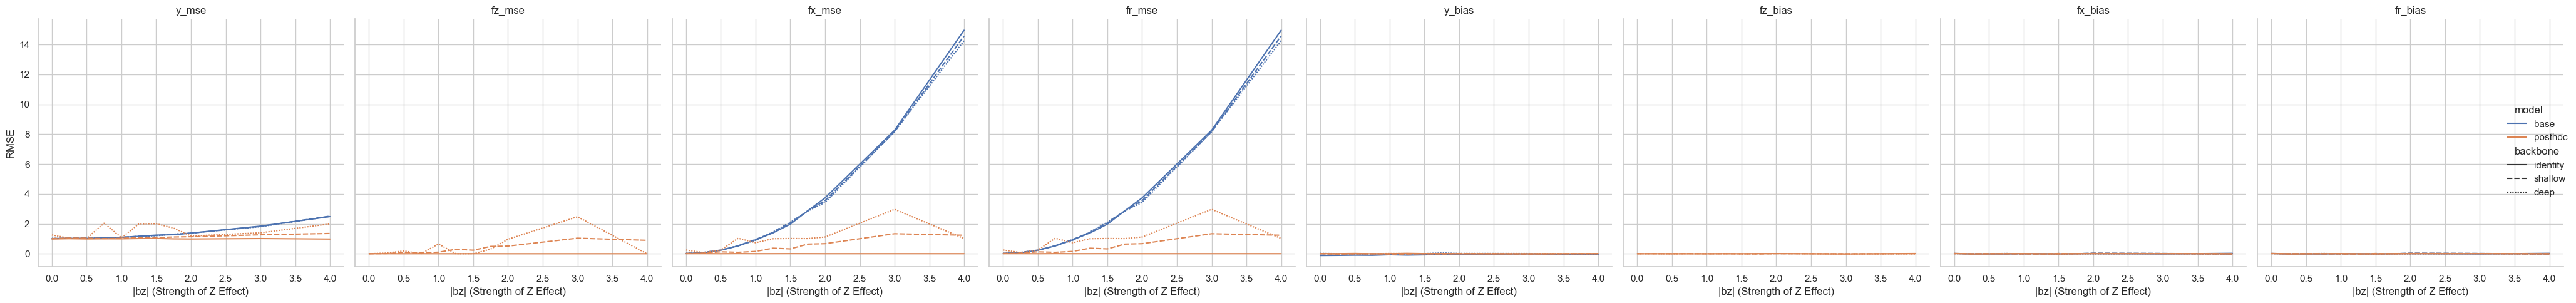

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Plot with confidence intervals over multiple runs
g = sns.relplot(
    data=all_df, kind="line",
    x="bz", y="metric_value", hue="model", style="backbone",
    col="metric_name", facet_kws={"sharey": True}
)

g.set_axis_labels("|bz| (Strength of Z Effect)", "RMSE")
g.set_titles(col_template="{col_name}")
g.add_legend()
plt.tight_layout()
plt.show()